# Mutual Fund Analytics Platform

## Exploratory Data Analysis (EDA)

### Bluestock Fintech Capstone

This notebook contains the exploratory data analysis performed on the cleaned mutual fund datasets.

## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

from pathlib import Path

plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (10,6)

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


## 2. Load Cleaned Datasets

In [2]:
base = Path("../data/processed")

nav = pd.read_csv(base / "clean_02_nav_history.csv")
aum = pd.read_csv(base / "clean_03_aum_by_fund_house.csv")
sip = pd.read_csv(base / "clean_04_monthly_sip_inflows.csv")
category = pd.read_csv(base / "clean_05_category_inflows.csv")
folio = pd.read_csv(base / "clean_06_industry_folio_count.csv")
performance = pd.read_csv(base / "clean_07_scheme_performance.csv")
transactions = pd.read_csv(base / "clean_08_investor_transactions.csv")
holdings = pd.read_csv(base / "clean_09_portfolio_holdings.csv")

print("All datasets loaded successfully.")

All datasets loaded successfully.


## 3. Dataset Overview

In [3]:
datasets = {
    "NAV": nav,
    "AUM": aum,
    "SIP": sip,
    "Category": category,
    "Folio": folio,
    "Performance": performance,
    "Transactions": transactions,
    "Holdings": holdings
}

summary = pd.DataFrame({
    "Dataset": datasets.keys(),
    "Rows": [df.shape[0] for df in datasets.values()],
    "Columns": [df.shape[1] for df in datasets.values()],
    "Missing Values": [df.isnull().sum().sum() for df in datasets.values()]
})

summary

,Dataset,Rows,Columns,Missing Values
0,NAV,46000,3,0
1,AUM,90,5,0
2,SIP,48,6,12
3,Category,144,3,0
4,Folio,21,6,0
5,Performance,40,19,0
6,Transactions,32778,13,0
7,Holdings,322,8,0


## 4. Data Types and Missing Values

In [4]:
for name, df in datasets.items():
    print("=" * 60)
    print(name)
    print("=" * 60)

    print("\nShape:")
    print(df.shape)

    print("\nData Types:")
    print(df.dtypes)

    print("\nMissing Values:")
    print(df.isnull().sum())

    print("\n")

NAV

Shape:
(46000, 3)

Data Types:
amfi_code      int64
date             str
nav          float64
dtype: object

Missing Values:
amfi_code    0
date         0
nav          0
dtype: int64


AUM

Shape:
(90, 5)

Data Types:
date                  str
fund_house            str
aum_lakh_crore    float64
aum_crore           int64
num_schemes         int64
dtype: object

Missing Values:
date              0
fund_house        0
aum_lakh_crore    0
aum_crore         0
num_schemes       0
dtype: int64


SIP

Shape:
(48, 6)

Data Types:
month                            str
sip_inflow_crore               int64
active_sip_accounts_crore    float64
new_sip_accounts_lakh        float64
sip_aum_lakh_crore           float64
yoy_growth_pct               float64
dtype: object

Missing Values:
month                         0
sip_inflow_crore              0
active_sip_accounts_crore     0
new_sip_accounts_lakh         0
sip_aum_lakh_crore            0
yoy_growth_pct               12
dtype: int64


Category

## 5. NAV Trend Analysis

In [5]:
nav["date"] = pd.to_datetime(nav["date"])

nav.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [6]:
nav.info()

<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   amfi_code  46000 non-null  int64         
 1   date       46000 non-null  datetime64[us]
 2   nav        46000 non-null  float64       
dtypes: datetime64[us](1), float64(1), int64(1)
memory usage: 1.1 MB


In [ ]:
fig = px.line(
    nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend of All Mutual Fund Schemes (2022–2026)",
    labels={
        "date": "Date",
        "nav": "NAV",
        "amfi_code": "AMFI Code"
    }
)

# Highlight 2023 Bull Run
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.12,
    layer="below",
    line_width=0,
    annotation_text="2023 Bull Run",
    annotation_position="top left"
)

# Highlight 2024 Market Correction
fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    fillcolor="red",
    opacity=0.10,
    layer="below",
    line_width=0,
    annotation_text="2024 Correction",
    annotation_position="top left"
)

fig.update_layout(
    template="plotly_white",
    height=650,
    hovermode="x unified"
)

fig.write_image(
    "../reports/supporting_files/charts/01_nav_trend.png",
    width=1400,
    height=800,
    scale=2
)

fig.show()

Resorting to unclean kill browser.


### Insight

- NAV values generally exhibit an upward trend across most mutual fund schemes from 2022 to 2025.
- Several schemes experienced temporary slowdowns during 2024 before recovering in 2025.
- Overall, the long-term trend indicates consistent growth in fund performance despite short-term market fluctuations.

## 6. AUM Growth by Fund House

In [ ]:
aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [ ]:
aum.info()

<class 'pandas.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            90 non-null     str    
 1   fund_house      90 non-null     str    
 2   aum_lakh_crore  90 non-null     float64
 3   aum_crore       90 non-null     int64  
 4   num_schemes     90 non-null     int64  
dtypes: float64(1), int64(2), str(2)
memory usage: 3.6 KB


In [ ]:
aum["date"] = pd.to_datetime(aum["date"])
aum["year"] = aum["date"].dt.year

aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes,year
0,2022-03-31,SBI Mutual Fund,6.05,605000,186,2022
1,2022-03-31,ICICI Prudential MF,4.65,465000,216,2022
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195,2022
3,2022-03-31,Nippon India MF,2.70,270000,177,2022
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168,2022


In [ ]:
fig = px.bar(
    aum,
    x="year",
    y="aum_lakh_crore",
    color="fund_house",
    barmode="group",
    title="AUM Growth by Fund House (2022–2025)",
    labels={
        "year": "Year",
        "aum_lakh_crore": "AUM (Lakh Crore)",
        "fund_house": "Fund House"
    }
)

fig.update_layout(
    template="plotly_white",
    height=650,
    xaxis=dict(type="category")
)

fig.write_image(
    "../reports/supporting_files/charts/02_aum_growth.png",
    width=1400,
    height=800,
    scale=2
)

fig.show()

### Insight

- Assets Under Management (AUM) increased steadily across major fund houses between 2022 and 2025.
- SBI Mutual Fund maintained the highest AUM throughout the observed period.
- Other leading AMCs, including ICICI Prudential and HDFC Mutual Fund, also showed consistent growth, reflecting increasing investor confidence.

## 7. SIP Inflow Analysis

In [ ]:
sip.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01,11517,4.91,9.10,4.80,NaN
1,2022-02,11438,4.93,8.20,4.85,NaN
2,2022-03,12328,5.09,10.50,5.01,NaN
3,2022-04,11863,5.48,9.52,5.12,NaN
4,2022-05,12286,5.55,8.10,5.15,NaN


In [ ]:
sip.info()

<class 'pandas.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   month                      48 non-null     str    
 1   sip_inflow_crore           48 non-null     int64  
 2   active_sip_accounts_crore  48 non-null     float64
 3   new_sip_accounts_lakh      48 non-null     float64
 4   sip_aum_lakh_crore         48 non-null     float64
 5   yoy_growth_pct             36 non-null     float64
dtypes: float64(4), int64(1), str(1)
memory usage: 2.4 KB


In [ ]:
sip["month"] = pd.to_datetime(sip["month"])

sip.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01-01,11517,4.91,9.10,4.80,NaN
1,2022-02-01,11438,4.93,8.20,4.85,NaN
2,2022-03-01,12328,5.09,10.50,5.01,NaN
3,2022-04-01,11863,5.48,9.52,5.12,NaN
4,2022-05-01,12286,5.55,8.10,5.15,NaN


In [ ]:
fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflow (2022–2025)",
    labels={
        "month": "Month",
        "sip_inflow_crore": "SIP Inflow (₹ Crore)"
    }
)

# Highlight December 2025
fig.add_vline(
    x="2025-12-01",
    line_dash="dash",
    line_color="red"
)

fig.add_annotation(
    x="2025-12-01",
    y=sip["sip_inflow_crore"].max(),
    text="₹31,002 Cr<br>Dec 2025",
    showarrow=True,
    arrowhead=2
)

fig.write_image(
    "../reports/supporting_files/charts/03_sip_inflow.png",
    width=1400,
    height=800,
    scale=2
)

fig.show()

### Insight

- SIP inflows show a steady upward trend from 2022 to 2025.
- The highest monthly SIP inflow is observed in December 2025.
- This indicates increasing investor participation and confidence in mutual funds over time.

## 8. Category Inflow Heatmap

In [ ]:
category.head()

,month,category,net_inflow_crore
0,2024-04,Large Cap,2413.0
1,2024-04,Mid Cap,3897.0
2,2024-04,Small Cap,3533.0
3,2024-04,Flexi Cap,4947.0
4,2024-04,Large & Mid Cap,4214.0


In [ ]:
category.info()

<class 'pandas.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   month             144 non-null    str    
 1   category          144 non-null    str    
 2   net_inflow_crore  144 non-null    float64
dtypes: float64(1), str(2)
memory usage: 3.5 KB


In [ ]:
category["month"] = pd.to_datetime(category["month"])
category["month"] = category["month"].dt.strftime("%b-%Y")

category.head()

,month,category,net_inflow_crore
0,Apr-2024,Large Cap,2413.0
1,Apr-2024,Mid Cap,3897.0
2,Apr-2024,Small Cap,3533.0
3,Apr-2024,Flexi Cap,4947.0
4,Apr-2024,Large & Mid Cap,4214.0


In [ ]:
category["month"] = pd.to_datetime(category["month"])

heatmap_data = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

heatmap_data = heatmap_data.sort_index(axis=1)

# Only for display
heatmap_data.columns = heatmap_data.columns.strftime("%b-%Y")

C:\Users\Admin\AppData\Local\Temp\ipykernel_2936\2839678052.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  category["month"] = pd.to_datetime(category["month"])


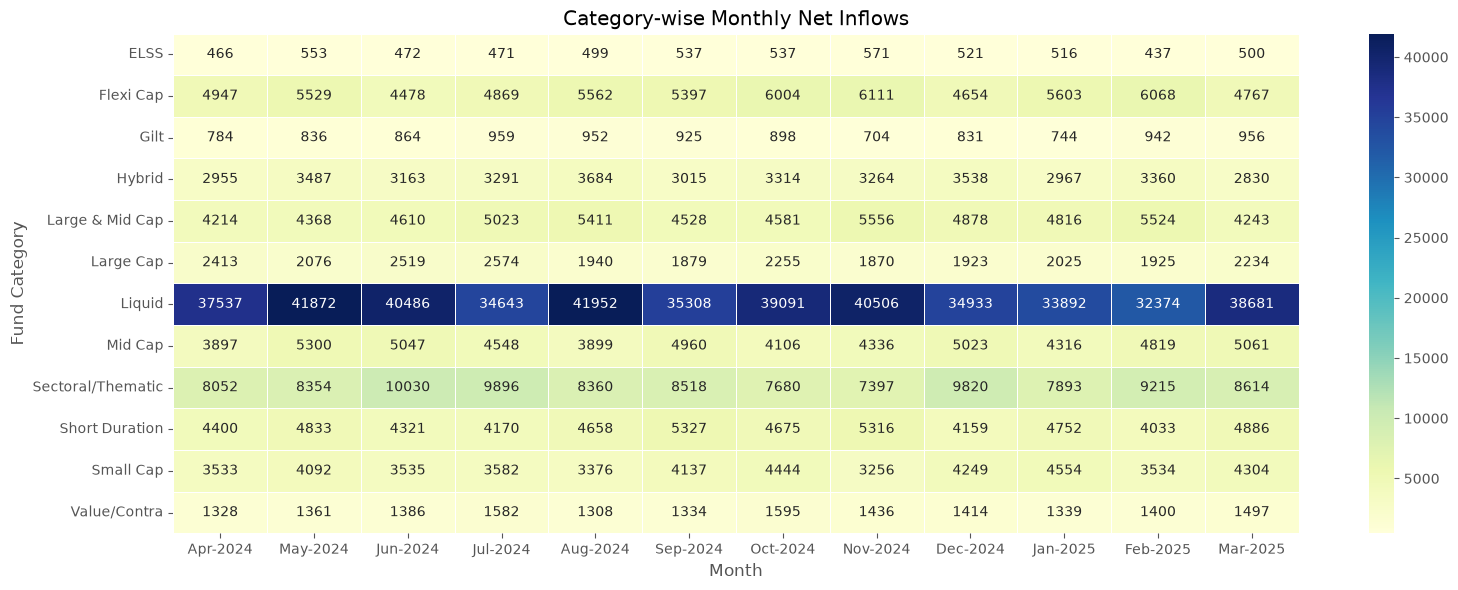

In [ ]:
plt.figure(figsize=(16, 6))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    annot=True,
    fmt=".0f",
    linewidths=0.5
)

plt.title("Category-wise Monthly Net Inflows")
plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.tight_layout()

plt.savefig(
    "../reports/supporting_files/charts/04_category_heatmap.png",
    dpi=400,
    bbox_inches="tight"
)

plt.show()

### Insight

- Net inflows vary across different mutual fund categories over time.
- Mid Cap, Small Cap and Flexi Cap categories receive strong inflows during several months.
- The heatmap clearly highlights periods of higher investor interest through darker color intensity.

## 9. Investor Demographics

In [ ]:
transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [ ]:
transactions.info()

<class 'pandas.DataFrame'>
RangeIndex: 32778 entries, 0 to 32777
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   investor_id         32778 non-null  str    
 1   transaction_date    32778 non-null  str    
 2   amfi_code           32778 non-null  int64  
 3   transaction_type    32778 non-null  str    
 4   amount_inr          32778 non-null  int64  
 5   state               32778 non-null  str    
 6   city                32778 non-null  str    
 7   city_tier           32778 non-null  str    
 8   age_group           32778 non-null  str    
 9   gender              32778 non-null  str    
 10  annual_income_lakh  32778 non-null  float64
 11  payment_mode        32778 non-null  str    
 12  kyc_status          32778 non-null  str    
dtypes: float64(1), int64(2), str(10)
memory usage: 3.3 MB


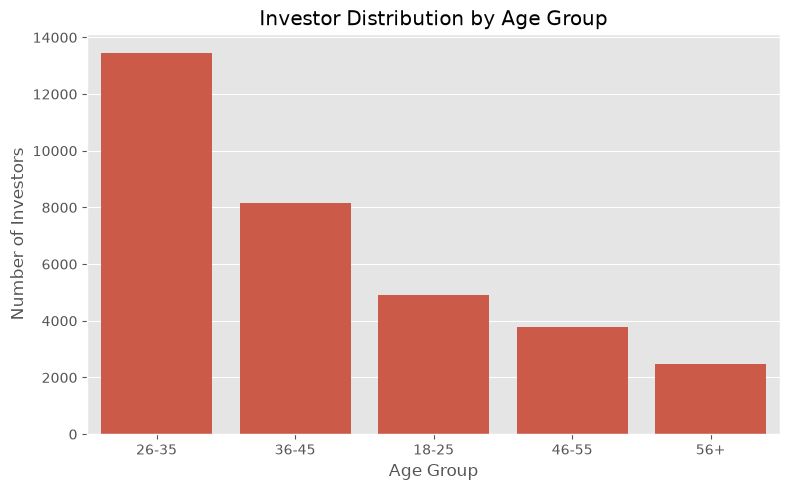

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=transactions,
    x="age_group",
    order=transactions["age_group"].value_counts().index
)

plt.title("Investor Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Investors")

plt.tight_layout()

plt.savefig(
    "../reports/supporting_files/charts/05_age_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight

- Investors aged 26–35 form the largest investor segment.
- Participation gradually decreases with increasing age.
- Working-age professionals dominate mutual fund investments.

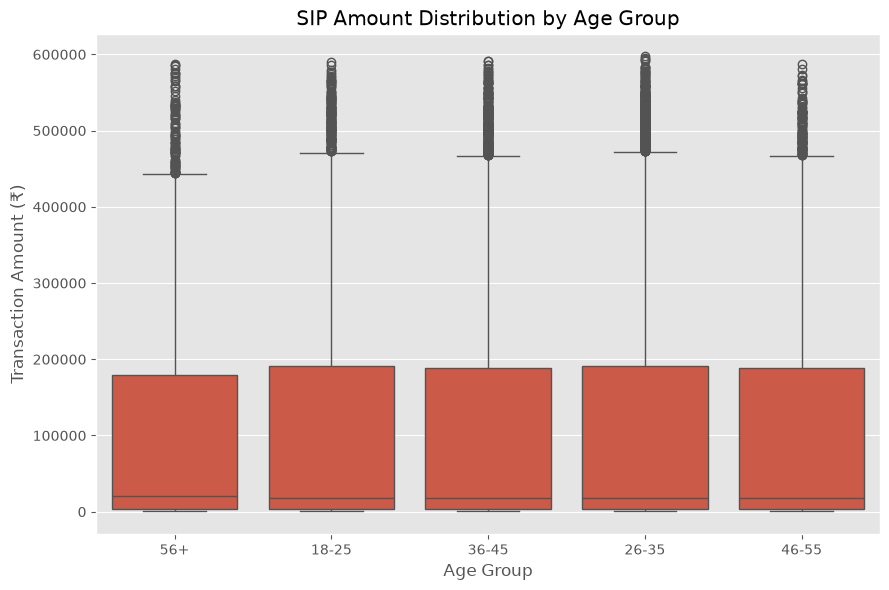

In [ ]:
plt.figure(figsize=(9,6))

sns.boxplot(
    data=transactions,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Transaction Amount (₹)")

plt.tight_layout()

plt.savefig(
    "../reports/supporting_files/charts/06_age_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight

- Median SIP investment amounts are comparable across age groups.
- Older investors show greater variability in investment size.
- High-value SIP outliers are present in every age category.

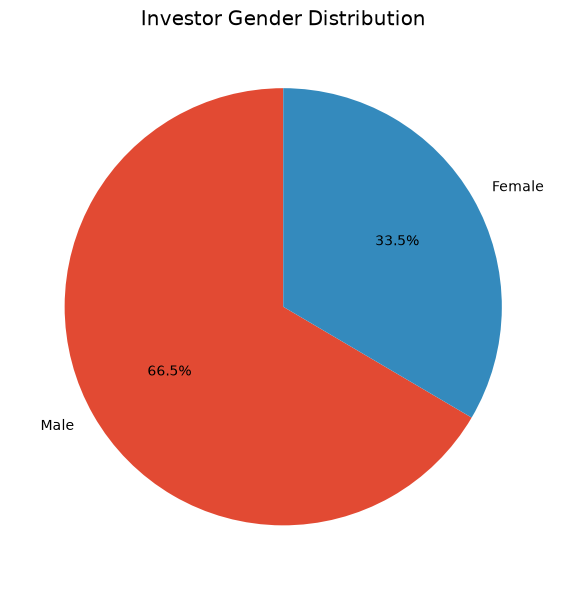

In [ ]:
plt.figure(figsize=(6,6))

transactions["gender"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Gender Distribution")
plt.ylabel("")

plt.tight_layout()

plt.savefig(
    "../reports/supporting_files/charts/07_gender_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight

- Male investors account for nearly two-thirds of all investors.
- Female participation represents a significant share of the investor base.
- The dataset indicates higher participation among male investors.

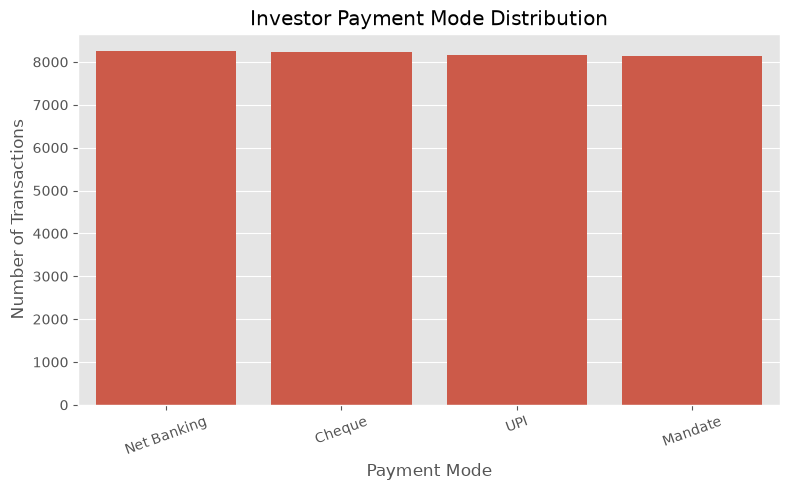

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=transactions,
    x="payment_mode",
    order=transactions["payment_mode"].value_counts().index
)

plt.title("Investor Payment Mode Distribution")
plt.xlabel("Payment Mode")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=20)

plt.tight_layout()

plt.savefig(
    "../reports/supporting_files/charts/08_payment_mode.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight

- Digital payment methods account for a large share of transactions.
- UPI, Net Banking and Mandates are commonly used for SIP investments.
- Investors show strong preference for online payment channels.

## 10. Geographic Distribution

In [ ]:
transactions["city_tier"].value_counts()

city_tier
T30    21719
B30    11059
Name: count, dtype: int64

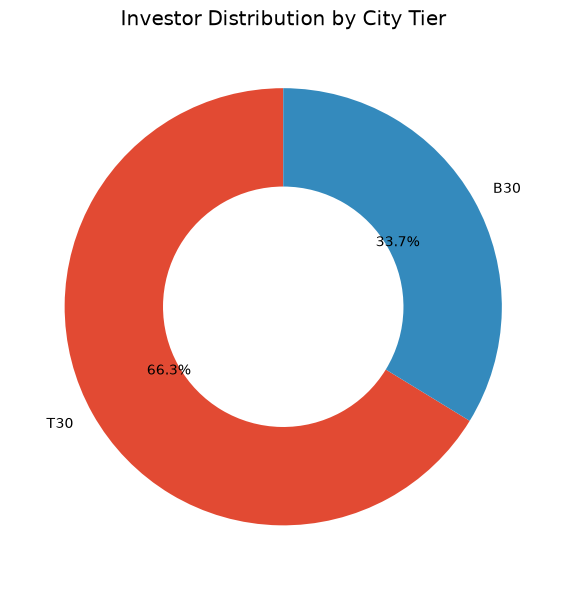

In [ ]:
plt.figure(figsize=(6, 6))

transactions["city_tier"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width":0.45}
)

plt.title("Investor Distribution by City Tier")
plt.ylabel("")

plt.tight_layout()

plt.savefig(
    "../reports/supporting_files/charts/10_city_tier.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight

- Around two-thirds of investors belong to T30 (Top 30) cities.
- B30 cities also contribute a significant share of investors.
- This suggests mutual fund adoption is still concentrated in metropolitan and large urban regions.

In [ ]:
state_amount = (
    transactions.groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

state_amount.head(10)

state
Punjab            315780459
Tamil Nadu        315177237
Madhya Pradesh    308312493
Rajasthan         298645822
Gujarat           298358940
West Bengal       297182514
Telangana         290219284
Delhi             289633404
Uttar Pradesh     285368873
Haryana           279634354
Name: amount_inr, dtype: int64

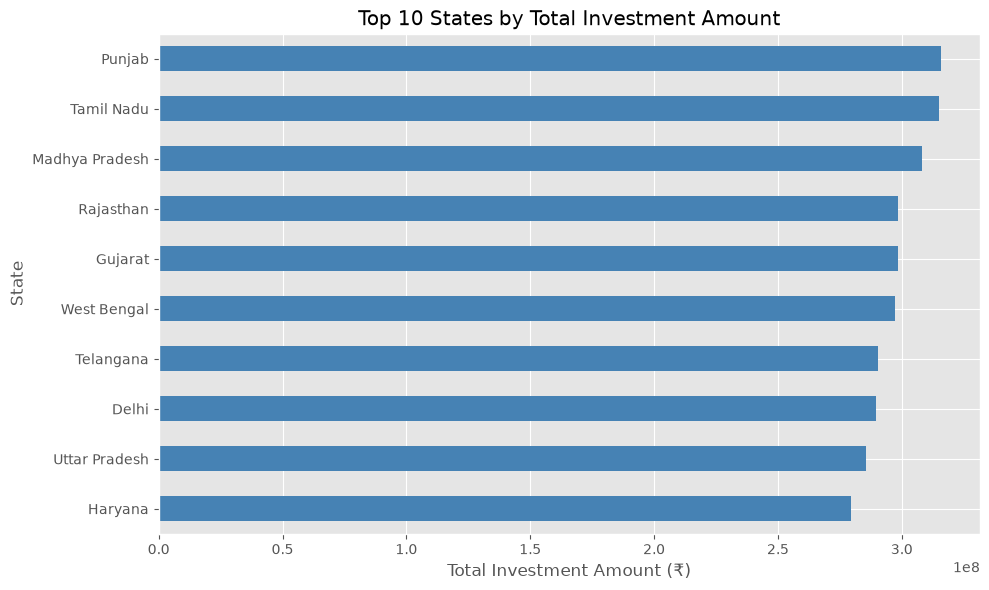

In [ ]:
top_states = state_amount.head(10).sort_values()

plt.figure(figsize=(10, 6))

top_states.plot(
    kind="barh",
    color="steelblue"
)

plt.title("Top 10 States by Total Investment Amount")
plt.xlabel("Total Investment Amount (₹)")
plt.ylabel("State")

plt.tight_layout()

plt.savefig(
    "../reports/supporting_files/charts/09_top_states.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight

- Punjab records the highest total investment amount in the dataset.
- Tamil Nadu, Madhya Pradesh, Rajasthan and Gujarat also contribute significantly.
- Investment activity is well distributed across multiple Indian states rather than being concentrated in a single region.

## 11. Portfolio Holdings Analysis

In [ ]:
holdings.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [ ]:
holdings.info()

<class 'pandas.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   amfi_code          322 non-null    int64  
 1   stock_symbol       322 non-null    str    
 2   stock_name         322 non-null    str    
 3   sector             322 non-null    str    
 4   weight_pct         322 non-null    float64
 5   market_value_cr    322 non-null    float64
 6   current_price_inr  322 non-null    float64
 7   portfolio_date     322 non-null    str    
dtypes: float64(3), int64(1), str(4)
memory usage: 20.3 KB


In [ ]:
sector_weight = (
    holdings.groupby("sector")["weight_pct"]
    .mean()
    .sort_values(ascending=False)
)

sector_weight

sector
Consumer Goods    14.178889
Diversified       12.087857
IT                11.386750
Utilities         11.064167
FMCG              10.910000
Banking           10.871000
NBFC              10.826364
Pharma            10.722368
Automobile         9.807576
Telecom            9.708000
Energy             9.070000
Paints             8.986000
Cement             8.752500
Infrastructure     8.734545
Name: weight_pct, dtype: float64

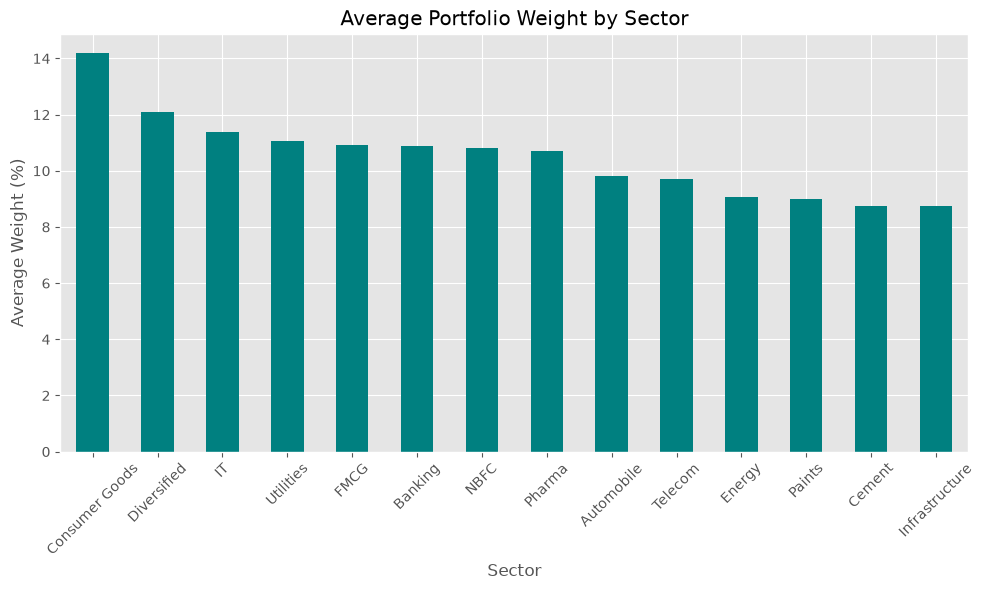

In [ ]:
plt.figure(figsize=(10,6))

sector_weight.plot(
    kind="bar",
    color="teal"
)

plt.title("Average Portfolio Weight by Sector")
plt.xlabel("Sector")
plt.ylabel("Average Weight (%)")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../reports/supporting_files/charts/11_sector_avg_weight.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight

- Consumer Goods, Diversified and IT sectors have the highest average portfolio weights.
- Most sectors maintain similar allocation levels, indicating balanced diversification.
- Portfolio exposure is distributed across multiple industries rather than concentrated in a single sector.

In [ ]:
top_holdings = (
    holdings.groupby("stock_name")["market_value_cr"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_holdings

stock_name
Axis Bank Ltd              16325.94
Bharti Airtel Ltd          16051.45
Reliance Industries Ltd    15286.54
NTPC Ltd                   13951.43
Grasim Industries Ltd      13897.79
Hindustan Unilever Ltd     12993.93
Mahindra & Mahindra Ltd    12967.27
HCL Technologies Ltd       12299.86
Tata Motors Ltd            12296.77
UltraTech Cement Ltd       11611.97
Name: market_value_cr, dtype: float64

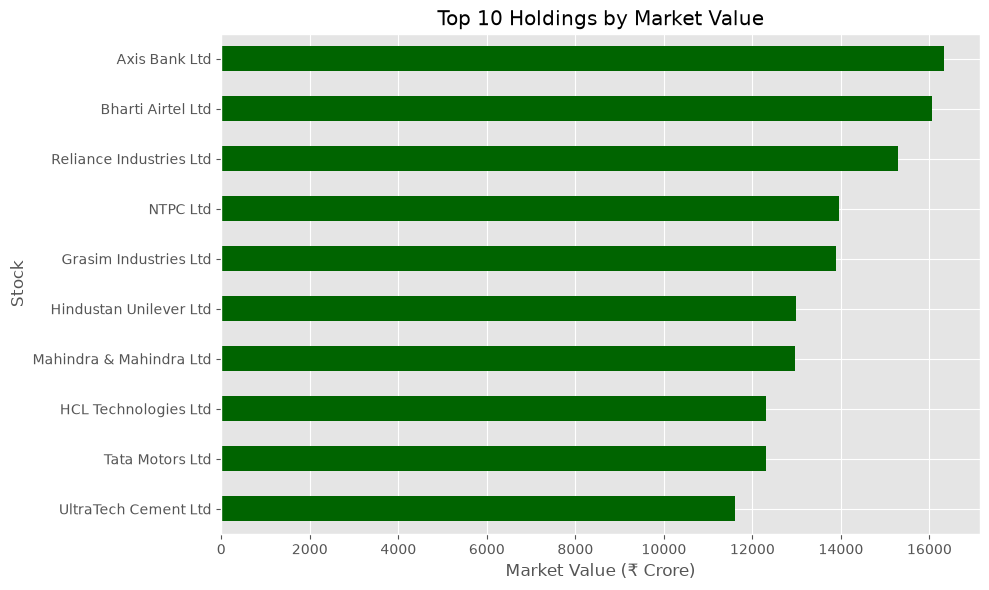

In [ ]:
plt.figure(figsize=(10,6))

top_holdings.sort_values().plot(
    kind="barh",
    color="darkgreen"
)

plt.title("Top 10 Holdings by Market Value")
plt.xlabel("Market Value (₹ Crore)")
plt.ylabel("Stock")

plt.tight_layout()

plt.savefig(
    "../reports/supporting_files/charts/12_top_holdings_market_value.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight

- Bharti Airtel Ltd. records the highest market value among the portfolio holdings.
- Reliance Industries, NTPC and Grasim Industries are also major portfolio constituents.
- Large-cap companies dominate the portfolio, reflecting preference for established businesses.

### Top 10 Stocks by Average Portfolio Weight

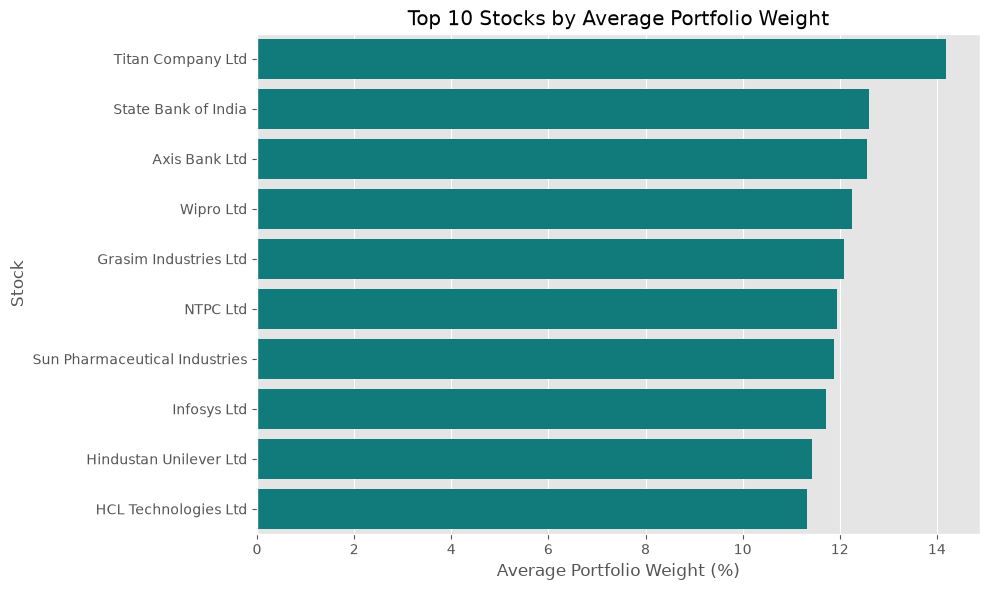

In [ ]:
top_weight = (
    holdings.groupby("stock_name")["weight_pct"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_weight.values,
    y=top_weight.index,
    color="darkcyan"
)

plt.title("Top 10 Stocks by Average Portfolio Weight")
plt.xlabel("Average Portfolio Weight (%)")
plt.ylabel("Stock")

plt.tight_layout()

plt.savefig(
    "../reports/supporting_files/charts/13_top_stock_weight.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
%who DataFrame

aum	 category	 df	 folio	 heatmap_data	 holdings	 nav	 performance	 sip	 
summary	 transactions	 


In [ ]:
print(globals().keys())

dict_keys(['__name__', '__doc__', '__package__', '__loader__', '__spec__', '__builtin__', '__builtins__', '_ih', '_oh', '_dh', 'In', 'Out', 'get_ipython', 'exit', 'quit', 'open', '_', '__', '___', '__vsc_ipynb_file__', '_i', '_ii', '_iii', '_i1', 'pd', 'np', 'plt', 'sns', 'px', 'go', 'Path', '_i2', 'base', 'nav', 'aum', 'sip', 'category', 'folio', 'performance', 'transactions', 'holdings', '_i3', 'datasets', 'summary', '_3', '_i4', 'name', 'df', '_i5', '_5', '_i6', '_i7', 'fig', '_i8', '_8', '_i9', '_i10', '_10', '_i11', '_i12', '_12', '_i13', '_i14', '_14', '_i15', '_i16', '_16', '_i17', '_i18', '_18', '_i19', 'heatmap_data', '_i20', '_i21', '_21', '_i22', '_i23', '_i24', '_i25', '_i26', '_i27', '_27', '_i28', '_i29', 'state_amount', '_29', '_i30', 'top_states', '_i31', '_31', '_i32', '_i33', 'sector_weight', '_33', '_i34', '_i35', 'top_holdings', '_35', '_i36', '_i37', 'top_weight', '_i38', '_i39'])


## 12. Folio Count Growth

In [ ]:
folio.head()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01,13.26,9.28,1.86,0.80,1.33
1,2022-04,13.91,9.74,1.95,0.83,1.39
2,2022-07,13.85,9.69,1.94,0.83,1.38
3,2022-10,14.12,9.88,1.98,0.85,1.41
4,2023-01,14.81,10.37,2.07,0.89,1.48


In [ ]:
folio["month"] = pd.to_datetime(folio["month"])

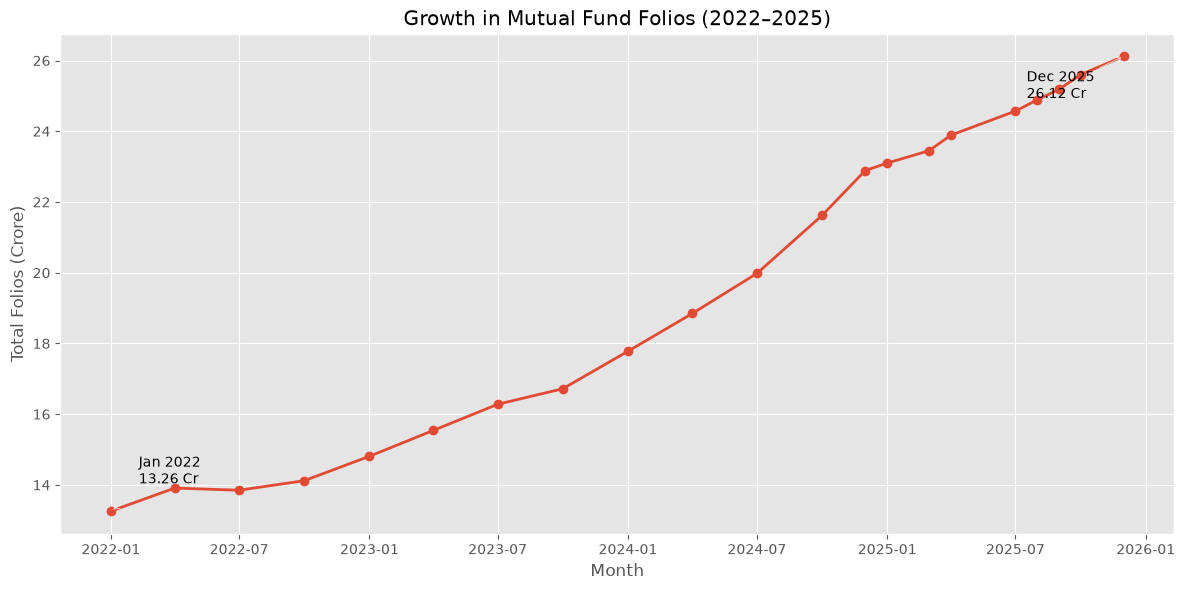

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    marker="o",
    linewidth=2
)

# Beginning
plt.annotate(
    "Jan 2022\n13.26 Cr",
    xy=(folio["month"].iloc[0], folio["total_folios_crore"].iloc[0]),
    xytext=(20,20),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->")
)

# End
plt.annotate(
    "Dec 2025\n26.12 Cr",
    xy=(folio["month"].iloc[-1], folio["total_folios_crore"].iloc[-1]),
    xytext=(-70,-30),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->")
)

plt.title("Growth in Mutual Fund Folios (2022–2025)")
plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../reports/supporting_files/charts/14_folio_growth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight

- Mutual fund folios increased steadily between 2022 and 2025.
- Total folios almost doubled during the observed period, indicating strong retail investor participation.
- Continuous growth reflects increasing awareness and adoption of mutual fund investments.

## 13. NAV Return Correlation Matrix

In [ ]:
nav["date"] = pd.to_datetime(nav["date"])

In [ ]:
selected_funds = nav["amfi_code"].unique()[:10]

selected_nav = nav[
    nav["amfi_code"].isin(selected_funds)
]

In [ ]:
nav_table = selected_nav.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

nav_table.head()

amfi_code,100016,100025,100033,119120,119551,119552,119598,119599,125497,125498
date,,,,,,,,,,
2022-01-03,520.4608,26.3169,107.3758,42.1391,54.3856,58.4174,89.8738,96.4565,560.1443,117.5969
2022-01-04,515.0971,26.2234,105.9447,42.2508,54.3474,57.3480,88.5495,94.6512,560.7052,117.0077
2022-01-05,521.7239,26.2221,105.4800,42.4374,54.6869,57.0552,88.0925,94.5436,563.0884,116.4011
2022-01-06,515.7880,26.1728,104.9350,42.5901,55.4550,56.4224,88.5175,93.7944,561.0675,116.0861
2022-01-07,515.1639,26.2261,104.3318,42.4851,55.3692,57.2750,91.4235,89.6438,559.5420,114.6164


In [ ]:
daily_returns = nav_table.pct_change().dropna()

daily_returns.head()

amfi_code,100016,100025,100033,119120,119551,119552,119598,119599,125497,125498
date,,,,,,,,,,
2022-01-04,-0.010306,-0.003553,-0.013328,0.002651,-0.000702,-0.018306,-0.014735,-0.018716,0.001001,-0.005010
2022-01-05,0.012865,-0.000050,-0.004386,0.004416,0.006247,-0.005106,-0.005161,-0.001137,0.004250,-0.005184
2022-01-06,-0.011377,-0.001880,-0.005167,0.003598,0.014045,-0.011091,0.004824,-0.007924,-0.003589,-0.002706
2022-01-07,-0.001210,0.002036,-0.005748,-0.002465,-0.001547,0.015111,0.032830,-0.044252,-0.002719,-0.012660
2022-01-10,-0.008639,0.006791,0.006277,-0.000353,-0.001548,0.009465,0.051113,0.033761,0.003057,-0.019536


In [ ]:
correlation = daily_returns.corr()

correlation

amfi_code,100016,100025,100033,119120,119551,119552,119598,119599,125497,125498
amfi_code,,,,,,,,,,
100016,1.000000,0.045567,-0.000006,-0.022521,0.040858,0.013663,-0.030296,-0.000007,0.047139,-0.016089
100025,0.045567,1.000000,0.002150,-0.040884,0.017017,-0.002803,-0.065019,-0.034061,0.011326,-0.025505
100033,-0.000006,0.002150,1.000000,-0.007166,-0.015559,-0.027471,0.006659,-0.028323,-0.025137,-0.011916
119120,-0.022521,-0.040884,-0.007166,1.000000,0.021601,-0.004003,0.018423,0.017795,-0.010542,-0.016315
119551,0.040858,0.017017,-0.015559,0.021601,1.000000,-0.006819,0.024409,-0.072559,0.016469,0.030454
119552,0.013663,-0.002803,-0.027471,-0.004003,-0.006819,1.000000,0.020754,-0.042415,0.027796,-0.052299
119598,-0.030296,-0.065019,0.006659,0.018423,0.024409,0.020754,1.000000,0.018187,-0.053278,0.018443
119599,-0.000007,-0.034061,-0.028323,0.017795,-0.072559,-0.042415,0.018187,1.000000,0.003347,0.041927
125497,0.047139,0.011326,-0.025137,-0.010542,0.016469,0.027796,-0.053278,0.003347,1.000000,0.027394


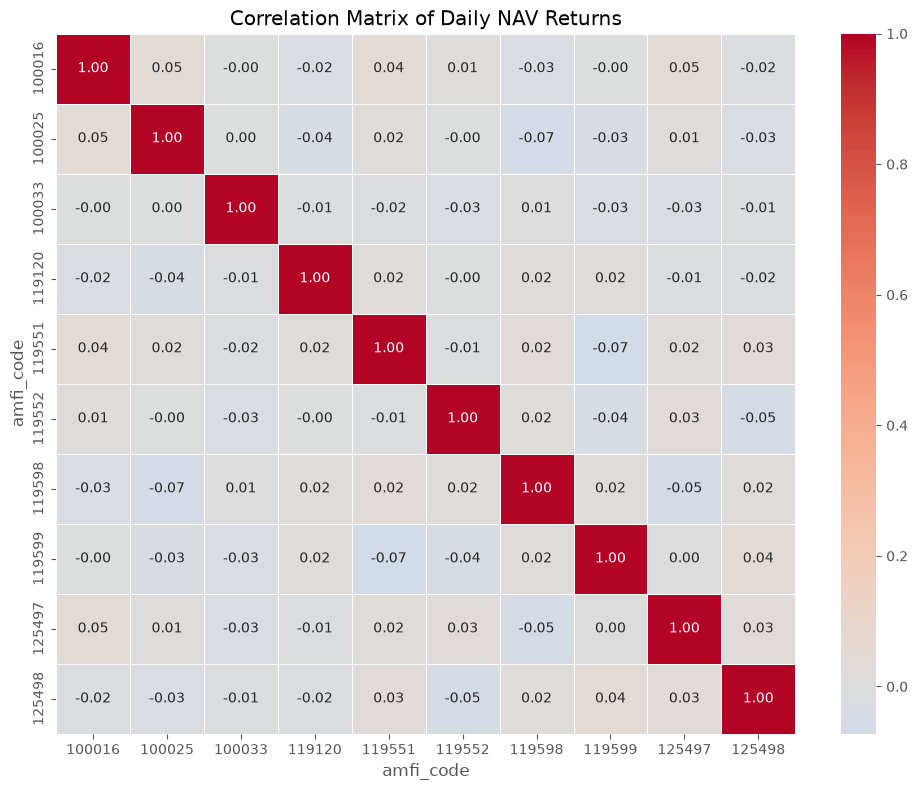

In [ ]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix of Daily NAV Returns")
plt.tight_layout()

plt.savefig(
    "../reports/supporting_files/charts/15_nav_correlation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight

- Most selected mutual funds show weak correlations in daily NAV returns.
- Correlation values remain close to zero, indicating diversified return movements.
- No pair of funds exhibits a very strong positive or negative correlation, suggesting good diversification across schemes.

## 14. Sector Allocation Donut

In [ ]:
holdings.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [ ]:
holdings.info()

<class 'pandas.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   amfi_code          322 non-null    int64  
 1   stock_symbol       322 non-null    str    
 2   stock_name         322 non-null    str    
 3   sector             322 non-null    str    
 4   weight_pct         322 non-null    float64
 5   market_value_cr    322 non-null    float64
 6   current_price_inr  322 non-null    float64
 7   portfolio_date     322 non-null    str    
dtypes: float64(3), int64(1), str(4)
memory usage: 20.3 KB


In [ ]:
sector_weight = (
    holdings.groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

sector_weight

sector
Banking           652.26
IT                455.47
Pharma            407.45
Automobile        323.65
Utilities         265.54
FMCG              229.11
Infrastructure    192.16
Diversified       169.23
Telecom           145.62
Consumer Goods    127.61
NBFC              119.09
Energy            117.91
Cement            105.03
Paints             89.86
Name: weight_pct, dtype: float64

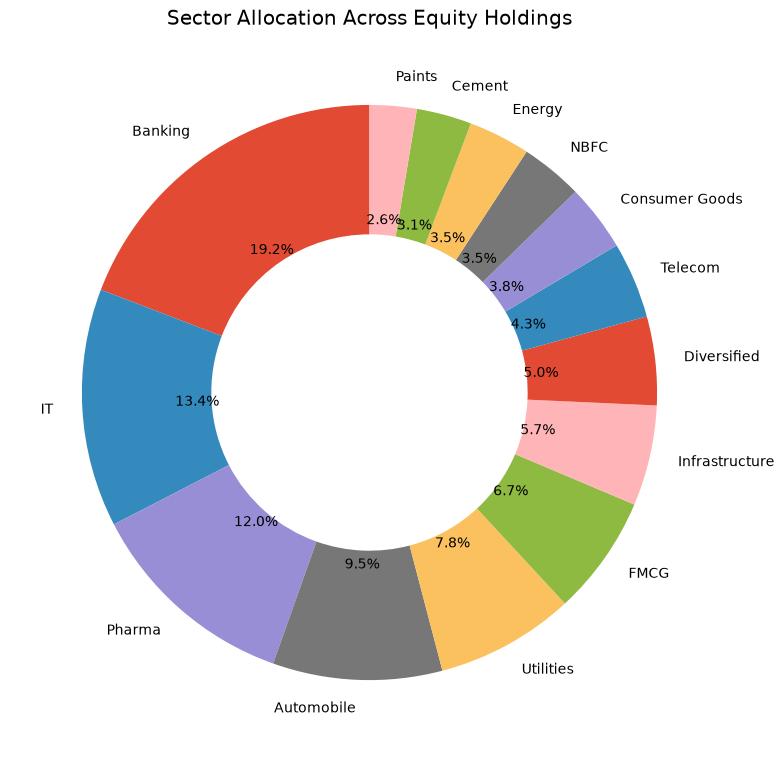

In [ ]:
plt.figure(figsize=(8,8))

plt.pie(
    sector_weight,
    labels=sector_weight.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width":0.45}
)

plt.title("Sector Allocation Across Equity Holdings")

plt.tight_layout()

plt.savefig(
    "../reports/supporting_files/charts/16_sector_allocation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight

- Banking, IT and Financial Services together account for a significant share of portfolio allocation.
- Sector diversification is maintained across Pharma, FMCG, Auto and Utilities.
- The allocation indicates a balanced investment strategy across multiple sectors rather than concentration in a single industry.

## 15. Key EDA Findings

1. Daily NAVs across all 40 mutual fund schemes showed an overall upward trend from 2022 to 2025, with visible market correction during 2024.

2. SBI Mutual Fund consistently maintained the highest Assets Under Management (AUM), reaching approximately ₹12.5 lakh crore by 2025.

3. Monthly SIP inflows steadily increased throughout the analysis period, reaching an all-time high of ₹31,002 crore in December 2025.

4. Flexi Cap, Mid Cap and Small Cap categories attracted consistently strong investor inflows, reflecting higher interest in equity-oriented funds.

5. Investors aged 26–35 formed the largest investor segment, indicating strong participation from young working professionals.

6. Approximately two-thirds of investors were male, while female participation accounted for roughly one-third of the investor base.

7. T30 cities contributed the majority of investments, although B30 cities also showed meaningful participation, highlighting expanding mutual fund adoption beyond metro areas.

8. Mutual fund folio count nearly doubled from 13.26 crore in January 2022 to 26.12 crore in December 2025, reflecting significant retail investor growth.

9. Daily NAV return correlations among the selected funds remained generally low, suggesting effective diversification across mutual fund schemes.

10. Banking, IT and Pharma sectors represented the largest portfolio allocations, while overall holdings remained diversified across multiple industries.